# Empirical Study

In this notebook, we study the empirical properties of the self-balancing sampler. Our main goal is to explore how the various predictability and convergence properties of the sampler depend on the parameter $\beta$. In particular, we saw that for any $c > 0$ that the limiting distribution induced by both $\beta$ and $c \beta$ is the same. Increasing $c$ makes the sampler more biased, causing it to converge faster at the cost of increased predictability. We aim to empirically quantify the trade-off between these two phenomenon. 

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

from tqdm import tqdm
import os 
from pathlib import Path

workdir = Path(os.getcwd())
image_folder = workdir / 'figs'

Set the relevant parameter values. Start by deciding on the relevant biases $\beta_i > 0$, and provide a list of possible scalings $c$ to compare.

In [194]:
# Parameter Values

beta = np.ones(4)  # uniform beta
#beta = np.array([1.1, 0.8, 0.9, 1.2])  # slightly non-uniform beta
beta = beta / np.linalg.norm(beta)  # normalize to unit vector

#scalings_c = [0.01, 0.05, 0.1,0.5, 1, 2] # compare c * beta for each c in scalings_c
scalings_c = np.logspace(-2, 1, num=10)  # logarithmically spaced scalings from 0.01 to 10

# number of trials and samples per trial
n_trials = 100
samples_per_trial = 10000

# Figure name conventions; save figures with path of the form image_folder/NAME_{suffix}.png
suffix = 'uniform'

assert np.isclose(np.sum(np.square(beta)), 1), "Beta must be a unit vector"
d = len(beta)

Define our sample probabilities and limiting distribution:

$$p_i(N) := \frac{e^{-\beta_i N_i}}{\sum_j e^{-\beta_j N_j}}, \quad p_i^* = \frac{\beta_i^{-1}}{\sum_j \beta_j^{-1}}$$

In [195]:
def p_beta(x, beta):
    '''
        Returns vector of probabilities where p_i is proportional to:
            e^{-beta x_i}
    '''
    logits = -beta * x
    logits = logits - np.max(logits)
    w = np.exp(logits)
    return w / w.sum()

def p_star(beta):
    '''
        Returns the limiting distribution p* for a given beta.
    '''
    return  (1 / beta) / np.sum(1 / beta)

Generate the given number of trials for the self-balancing sampler. For each trial, we keep track of a few running statistics:

* The total variation distance $||\mu_n - p^*||_{TV}$ from the limiting distribution after $n$ samples. 
* The "predictability": how often the sampled index is the most under-sampled one (ties broken arbitrarily).

In [196]:
# Generate samples

num_c = len(scalings_c)
# An array of all the sampled points across all trials.
samples = np.zeros((num_c, n_trials, samples_per_trial))
tv_distances = np.zeros((num_c, n_trials, samples_per_trial))
correct_predictions = np.zeros((num_c, n_trials, samples_per_trial))
expected_prediction_accuracy = np.zeros((num_c, n_trials, samples_per_trial))

p_limit = p_star(beta)

for i, c in enumerate(scalings_c):
    for trial in tqdm(range(n_trials)):

        X_n = np.zeros(d)

        for n in range(samples_per_trial):
            p = p_beta(X_n, c * beta)
            next_sample = np.random.choice(range(d), p=p)

            weighted_counts = beta * X_n
            most_undersampled = np.flatnonzero(np.isclose(weighted_counts, weighted_counts.min()))

            correct_predictions[i, trial, n] = int(next_sample in most_undersampled) / len(most_undersampled)
            expected_prediction_accuracy[i, trial, n] = p[most_undersampled].sum() / len(most_undersampled)

            X_n[next_sample] += 1
            samples[i, trial, n] = next_sample

            mu_n = X_n / (n+1)
            tv_distances[i, trial, n] = 0.5 * np.sum(np.abs(mu_n - p_limit))

fraction_correct_all = np.mean(correct_predictions, axis=2)
expected_accuracy_all = np.mean(expected_prediction_accuracy, axis=2)

# By default, estimate predictability from the tail of the run so the small-c transient
# does not dominate the comparison with the asymptotic baseline p_max^*.
predictability_tail_fraction = 0.1
predictability_start = int((1 - predictability_tail_fraction) * samples_per_trial)
fraction_correct = np.mean(correct_predictions[:, :, predictability_start:], axis=2)
expected_accuracy = np.mean(expected_prediction_accuracy[:, :, predictability_start:], axis=2)

100%|██████████| 100/100 [00:37<00:00,  2.66it/s]


### Convergence Rate

Recall that the paper proves the convergence rate is $O(n^{-1})$. We want to identify the relevant constant. Since we expect:

$$||\mu_n - p^*||_{TV} = \frac{A(\beta)}{n} + \frac{B(\beta)}{n^2} + o(n^{-2}) \to n||\mu_n - p^*||_{TV}= A - \frac{B}{n} + o(n^{-1})$$

 we can estimate $A$ by simulating enough samples for each trial until $n \cdot TV$ converges, waiting for the lower order terms to die off, and taking the asymptotic value of $n \cdot TV$. Since the limiting distribution $p^*$ is unaffected when the weights $\beta$ are scaled by some constant factor ($p^*(\beta) = p^*(c\beta)$ for any $c > 0$) we also hope to understand how this constant $A$ or any lower-order terms depends on this factor.

Let's start by just plotting $n \cdot TV$ to see this in action.

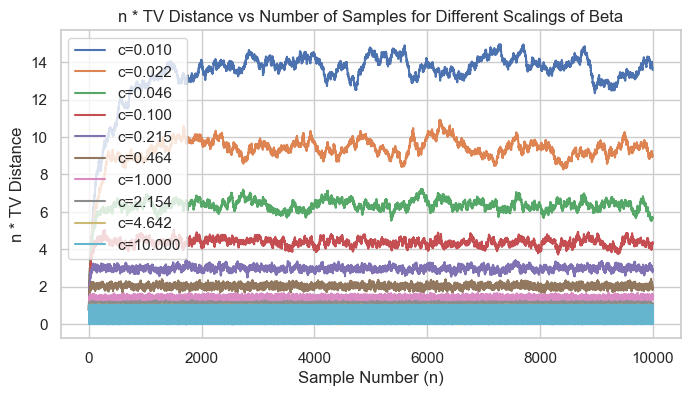

In [201]:
n = np.arange(1, tv_distances.shape[2] + 1)
scaled_tv_distances = tv_distances * n  # broadcasts over last axis
mean_tv_distances = np.mean(scaled_tv_distances, axis=1)

plt.figure(figsize=(8, 4))

for i, c in enumerate(scalings_c):
    plt.plot(mean_tv_distances[i], label=f"c={c:.3f}")

plt.title(f"n * TV Distance vs Number of Samples for Different Scalings of Beta")
plt.xlabel("Sample Number (n)")
plt.ylabel("n * TV Distance")
plt.legend()
plt.show()

We observe above that the value tends to stabilize as the lower-order terms die off. If we want to get a sense of what the leading constant is, and how it varies with $c$ as we scale $\beta$, we can plot this limiting value as a function of $c$. We do that below. Since the curves still fluctuate, we average the last few values of the process to get a more reasonable estimate of this asymptotic value.

From our analysis in the paper, we expect the behavior to be either $O(c^{-1/2})$ or $O(c^{-1})$, so to separate these two we look at the slope on a log-log plot. The former occurs when $\beta$ is uniform, and the latter when it is not. 

Beta =  [0.5 0.5 0.5 0.5]
Beta is uniform; expect c^{-1/2} behavior in small c regime


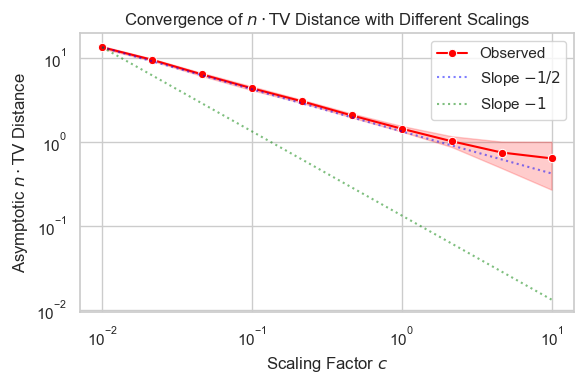

In [202]:
# fraction of values to use to estimate asymptotic TV distance
fraction_values = 0.1 

print('Beta = ', np.round(beta, 3))

if np.all(np.isclose(beta, beta[0])):
    print("Beta is uniform; expect c^{-1/2} behavior in small c regime")
else:
    print("Beta is not uniform; expect c^{-1} behavior in small c regime")

num_values = int(fraction_values * samples_per_trial)
means_conv = mean_tv_distances[:, -num_values:].mean(axis=1)
std_devs = mean_tv_distances[:, -num_values:].std(axis=1)

# reference slopes
c0 = scalings_c[0]
y0 = means_conv[0]
slope_minus_half = y0 * (scalings_c / c0) ** (-0.5)
slope_minus_one = y0 * (scalings_c / c0) ** (-1.0)

# seaborn style
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(6, 4))

# observed curve
sns.lineplot(
    x=scalings_c,
    y=means_conv,
    marker="o",
    color="red",
    label="Observed"
)

# uncertainty band
plt.fill_between(
    scalings_c,
    means_conv - std_devs,
    means_conv + std_devs,
    alpha=0.2,
    color="red"
)

# reference slope lines
sns.lineplot(
    x=scalings_c,
    y=slope_minus_half,
    linestyle=":",
    color="blue",
    alpha=0.5,
    label=r"Slope $-1/2$"
)

sns.lineplot(
    x=scalings_c,
    y=slope_minus_one,
    linestyle=":",
    color="green",
    alpha=0.5,
    label=r"Slope $-1$"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Scaling Factor $c$")
plt.ylabel(r"Asymptotic $n \cdot \mathrm{TV}$ Distance")
plt.title(r"Convergence of $n \cdot \mathrm{TV}$ Distance with Different Scalings")
plt.legend()
plt.tight_layout()

filepath = image_folder / f'convergence_plot_{suffix}.png'
plt.savefig(filepath)
plt.show()

### Predictability

We compare the predictability against our two baselines: deterministic (aka greedy) sampling and iid sampling. 

For the uniform $\beta$ case, using the former we expect roughly $\frac{H_d}{d} \approx \frac{\log(d)}{d}$ answers to be correct, where $H_d$ is the $d^{th}$ harmonic number. In the latter, we expect roughly $\frac{1}{d}$ answers to be correct.

For the non-uniform $\beta$ case, greedy sampling becomes almost more predictable, as there is often only a single index that is most under-sampled. If the $\beta_i$ differ by rational factors, then sometimes this is not the case, but otherwise it is generally true. Hence the predictability is almost one. On the other hand, for iid sampling clearly the optimal thing to do is to predict the index $i = \arg\max_\ell p_\ell^*$ that is most likely to be sampled.

Recall that in the paper we heuristically show two factors govern the predictability in the small $\beta$ regime: (i) the maximum $max_i p_i^*$ and (ii) the number of indices $k$ achieving this maximum. In particular, we showed in this small $\beta$ regime that the fraction correct is approximately:

$$\max_i p_i^* +  \sqrt{\frac{\log | I^*|}{\beta_{min} S_\beta^2}} + O(\beta), \quad S_\beta = \sum_j \beta_j^{-1}$$

at least in the regime where $|I^*|$ is large, so classical asymptotics for maximums of iid gaussians apply. In the case of uniform $\beta$, we saw this simplified to:

$$\max_i p_i^* +  \frac{\sqrt{\beta \log(d)}}{d} + O(\beta).$$

 Hence we see there are two regimes roughly: an $\Theta(\sqrt{c})$ regime that occurs when the maximum is not unique, and a $O(c)$ regime that occurs when the maximum of $p_i^*$ is unique. If:

 $$\Delta(c) := \text{fraction correct} - \max p_i^*$$

 then we can differentiate between these two regimes by plotting $\frac{\Delta(c)}{\sqrt{c}}$ and $\frac{\Delta(c)}{c}$ and seeing which converges to a nonzero limit in the small $c$ regime. 

Beta =  [0.5 0.5 0.5 0.5]
Maximum of p^* is not unique; expect O(c^{1/2}) behavior in small c regime


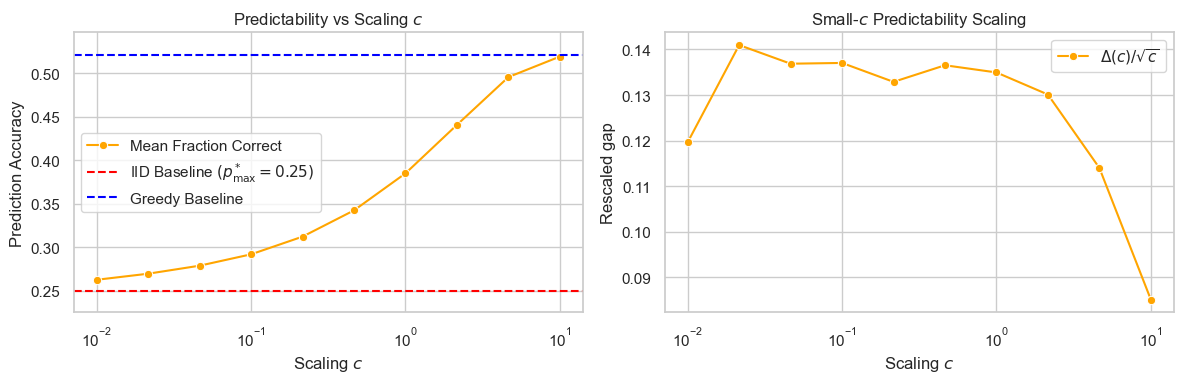

In [205]:
def harmonic_number(n):
    return np.sum(1.0 / np.arange(1, n + 1))

def deterministic_predictability(beta, T=10000):
    """
    Empirical estimate of the predictability of the greedy guessing strategy
    for a given beta.
    """
    beta = np.asarray(beta, dtype=float)
    d = len(beta)
    N = np.zeros(d, dtype=int)
    success = 0.0

    for _ in range(T):
        weighted = beta * N
        m = np.flatnonzero(np.isclose(weighted, weighted.min()))
        success += 1.0 / len(m)

        # sampler tie-breaks uniformly
        i = np.random.choice(m)
        N[i] += 1

    return success / T


print("Beta = ", np.round(beta, 3))

if np.sum(np.isclose(beta, np.min(beta))) > 1:
    print("Maximum of p^* is not unique; expect O(c^{1/2}) behavior in small c regime")
else:
    print("Maximum of p^* is unique; expect O(c) behavior in small c regime")


p_max = np.max(p_limit)
greedy_predictability = deterministic_predictability(beta)

mean_fraction_correct_all = fraction_correct_all.mean(axis=1)
mean_fraction_correct = fraction_correct.mean(axis=1)
std_fraction_correct = fraction_correct.std(axis=1)
mean_expected_accuracy = expected_accuracy.mean(axis=1)
std_expected_accuracy = expected_accuracy.std(axis=1)
delta_predictability = mean_fraction_correct - p_max


fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Axis 1: raw predictability
ax = axs[0]


sns.lineplot(
    x=scalings_c,
    y=mean_fraction_correct_all,
    color='orange',
    marker="o",
    ax=ax,
    label="Mean Fraction Correct",
)

ax.axhline(
    p_max,
    linestyle="--",
    color="red",
    label=rf"IID Baseline $(p_{{\max}}^* = {p_max:.2f})$",
)

if np.all(np.isclose(beta, beta[0])):
    ax.axhline(
        harmonic_number(d) / d,
        linestyle="--",
        color="blue",
        label="Greedy Baseline",
    )
else:
    ax.axhline(
        greedy_predictability,
        linestyle="--",
        color="blue",
        label="Greedy Baseline",
    )

ax.set_xscale("log")
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Prediction Accuracy")
ax.set_title(r"Predictability vs Scaling $c$")
ax.legend(loc="best")
ax.set_ylim([0.9*p_max, 1.05 * greedy_predictability])


# Axis 2: small-c scaling diagnostic
ax = axs[1]

sns.lineplot(
    x=scalings_c,
    y=delta_predictability / np.sqrt(scalings_c),
    marker="o",
    ax=ax,
    color='orange',
    label=r"$\Delta(c) / \sqrt{c}$",
)

# sns.lineplot(
#     x=scalings_c,
#     y=delta_predictability / scalings_c,
#     marker="o",
#     ax=ax,
#     label=r"$\Delta(c) / c$",
# )

ax.set_xscale("log")
ax.set_xlabel(r"Scaling $c$")
ax.set_ylabel("Rescaled gap")
ax.set_title(r"Small-$c$ Predictability Scaling")
ax.legend(loc="upper right")
plt.tight_layout()

filepath = image_folder / f'predictability_{suffix}.png'
plt.savefig(filepath)
plt.show()

### Trade-off

Now, we study the trade-off between predictability and convergence rate. Recall that the asymptotic value of $n \cdot TV$ is some measure of the coefficient $An^{-1}$ in the leading term of the average convergence rate, so it is in a sense a measure of the (inverse) convergence rate.

Beta =  [0.5 0.5 0.5 0.5]


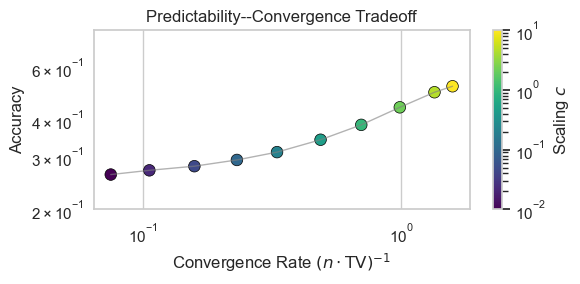

In [200]:
sns.set_theme(style="whitegrid", context="notebook")

print("Beta = ", np.round(beta, 3))

x_vals = 1 / means_conv
y_vals = mean_fraction_correct 

fig, ax = plt.subplots(figsize=(6, 3))

# Connect the points to show trajectory
ax.plot(
    x_vals,
    y_vals,
    linestyle="-",
    linewidth=1,
    alpha=0.6,
    color="gray",
)

# Color points by scaling c
norm = mpl.colors.LogNorm(vmin=np.min(scalings_c), vmax=np.max(scalings_c))
scatter = ax.scatter(
    x_vals,
    y_vals,
    c=scalings_c,
    norm=norm,
    cmap="viridis",
    s=70,
    edgecolor="black",
    linewidth=0.5,
)

# Colorbar for c values
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(r"Scaling $c$")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Convergence Rate $(n \cdot \mathrm{TV})^{-1}$")
ax.set_ylabel("Accuracy")
ax.set_title(r"Predictability--Convergence Tradeoff")

#ax.set_ylim([p_max * 0.9, 1.1 * greedy_predictability])
ax.set_ylim([0.2, 0.8])
plt.tight_layout()

filepath = image_folder / f'tradeoff_{suffix}.png'
plt.savefig(filepath)


plt.show()

## Citizen's Assembly.

In this section, we simulate the self-balancing sampler on the citizen's assembly problem discussed in Section 13 of [Flanigan et al.](https://procaccia.info/wp-content/uploads/2021/08/assemblies.pdf). The setting is as follows:

> Say that we want to select an assembly of $k = 200$ people that includes at least $99$ of
> each category: women, men, liberals, and conservatives. Let the pool consist of $1,000$
> conservative men, $999$ liberal women, and $1$ conservative woman. 

The goal is to generate such an assemly meeting the desired quota, where each individual in the pool has a reasonable chance of being selected. Namely, we want to maximize the
minimal probability a specific individual is being sampled according to the sampling scheme, so that each individual is as fairly represented as possible.

Note that the stratified sampling algorithm that selects 100 uniformly drawn women and 100 uniformly 
drawn men satisfies the quotas and selects each pool member with equal probability $10\%$. On the other hand, the *LEGACY* algorithm discussed in [Flanigan et al.](https://procaccia.info/wp-content/uploads/2021/08/assemblies.pdf) has only a $0.2 \%$ chance of selecting the conservative woman. 

We propose two strategy that sequentially samples individuals. 
1. A stratified sampling approach, where we choose the feature vector from $\{\text{man}, \text{woman}\} \times \{\text{conservative}, \text{liberal}\}$ using the self-balancing sampler, and then uniformly choose an individual from the given class. The relative weights $(\beta_i^{-1})_{i=1}^4$ are chosen proportional to the initial class size. This ensures at stationarity that individuals are selected uniformly at random from the total population. 

2. Each individual is given weight proportional to $\exp(-\beta_{gender} N_{gender} - \beta_{party} N_{party})$. This is akin to running two copies of the self-balancing sampler, one for the gender and one for the party, and then selecting an individual uniformly at random from the selected gender/party class. 

We hope to show:
* The quotas are satisfied with high probability.
* Each individual is selected reasonably often.  

Moreover, we hope this is true regardless of the distribution of men/women and conservatives/liberals. 

To get a sense of this, we simulate sampling many assemblies **without replacement** according to these two rules. Across many runs we record:

1. The gender and party margins of the final assembly.
2. Whether the assembly satisfies the quota of at least `99` in each of the four categories.
3. For each individual, the empirical probability of being selected into the assembly.

Below, we visualize some of the results


In [109]:
# Parameters
assembly_size = 200 # k

class_sizes = np.zeros((2,2), dtype=int)
class_sizes[0, 0] = 1000 # conservative men
class_sizes[0, 1] = 1 # conservative women
class_sizes[1, 0] = 0 # liberal men
class_sizes[1, 1] = 999 # liberal women

total_population = class_sizes.sum()

# Simulation parameters
n_assembly_runs = 3000
beta_scaling = 1.0
beta_gender = 1.0
beta_party = 1.0

Simulate many sampled assemblies. 

In [110]:
GENDER_NAMES = np.array(["man", "woman"])
PARTY_NAMES = np.array(["conservative", "liberal"])
CLASS_NAMES = np.array([
    "conservative men",
    "conservative women",
    "liberal men",
    "liberal women",
])

party_of_class = np.array([0, 0, 1, 1])
gender_of_class = np.array([0, 1, 0, 1])
flat_class_sizes = class_sizes.reshape(-1)

assert assembly_size <= total_population, "Assembly size cannot exceed the total population."

individual_class = np.repeat(np.arange(4), flat_class_sizes)
class_member_ids = [np.flatnonzero(individual_class == c) for c in range(4)]


def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    logits = logits - np.max(logits)
    weights = np.exp(logits)
    return weights / weights.sum()


def draw_from_probs(rng, probs):
    return rng.choice(len(probs), p=probs)


def summarize_margin_counts(class_counts):
    return {
        "men": int(class_counts[0] + class_counts[2]),
        "women": int(class_counts[1] + class_counts[3]),
        "conservative": int(class_counts[0] + class_counts[1]),
        "liberal": int(class_counts[2] + class_counts[3]),
    }


def quota_satisfied(class_counts, quota=99):
    margins = summarize_margin_counts(class_counts)
    return all(margins[name] >= quota for name in margins)


def run_stratified_class_sampler(rng, assembly_size, class_sizes, beta_scaling=1.0):
    """
    Run the class-level self-balancing sampler without replacement.
    The target class frequencies are based on the scaled weights
    beta_scaling * class_size / total_population, while individuals are
    still treated symmetrically within each class.
    """
    flat_sizes = class_sizes.reshape(-1)
    total_population = flat_sizes.sum()
    beta_class = np.full(4, np.inf)
    positive = flat_sizes > 0
    beta_inv = beta_scaling * flat_sizes[positive] / total_population
    beta_class[positive] = 1.0 / beta_inv

    remaining = flat_sizes.copy()
    class_counts = np.zeros(4, dtype=int)
    chosen_ids = np.empty(assembly_size, dtype=int)
    class_orders = [rng.permutation(ids) for ids in class_member_ids]
    class_ptrs = np.zeros(4, dtype=int)

    for t in range(assembly_size):
        active = np.flatnonzero(remaining > 0)
        probs = softmax(-beta_class[active] * class_counts[active])
        chosen_class = active[draw_from_probs(rng, probs)]

        chosen_ids[t] = class_orders[chosen_class][class_ptrs[chosen_class]]
        class_ptrs[chosen_class] += 1
        class_counts[chosen_class] += 1
        remaining[chosen_class] -= 1

    return chosen_ids, class_counts


def run_attribute_balanced_sampler(rng, assembly_size, class_sizes, beta_gender=1.0, beta_party=1.0):
    """
    Sample individuals without replacement using multiplicative weights built
    from the current gender and party counts in the partial assembly.
    """
    flat_sizes = class_sizes.reshape(-1)
    remaining = flat_sizes.copy()
    gender_counts = np.zeros(2, dtype=int)
    party_counts = np.zeros(2, dtype=int)
    class_counts = np.zeros(4, dtype=int)
    chosen_ids = np.empty(assembly_size, dtype=int)
    class_orders = [rng.permutation(ids) for ids in class_member_ids]
    class_ptrs = np.zeros(4, dtype=int)

    for t in range(assembly_size):
        active = np.flatnonzero(remaining > 0)
        logits = (
            np.log(remaining[active])
            - beta_gender * gender_counts[gender_of_class[active]]
            - beta_party * party_counts[party_of_class[active]]
        )
        probs = softmax(logits)
        chosen_class = active[draw_from_probs(rng, probs)]

        chosen_ids[t] = class_orders[chosen_class][class_ptrs[chosen_class]]
        class_ptrs[chosen_class] += 1
        class_counts[chosen_class] += 1
        gender_counts[gender_of_class[chosen_class]] += 1
        party_counts[party_of_class[chosen_class]] += 1
        remaining[chosen_class] -= 1

    return chosen_ids, class_counts


In [111]:
rng = np.random.default_rng(20260426)

samplers = {
    "Stratified self-balancing over classes": lambda rng: run_stratified_class_sampler(
        rng,
        assembly_size=assembly_size,
        class_sizes=class_sizes,
        beta_scaling=beta_scaling,
    ),
    "Attribute-balanced individual sampler": lambda rng: run_attribute_balanced_sampler(
        rng,
        assembly_size=assembly_size,
        class_sizes=class_sizes,
        beta_gender=beta_gender,
        beta_party=beta_party,
    ),
}

assembly_records = []
selection_probability_frames = []

for rule_name, sampler in samplers.items():
    selected_count_by_individual = np.zeros(total_population, dtype=int)

    for _ in tqdm(range(n_assembly_runs), desc=rule_name):
        selected_ids, class_counts = sampler(rng)
        selected_count_by_individual[selected_ids] += 1
        margin_counts = summarize_margin_counts(class_counts)

        assembly_records.append({
            "rule": rule_name,
            "conservative men": int(class_counts[0]),
            "conservative women": int(class_counts[1]),
            "liberal men": int(class_counts[2]),
            "liberal women": int(class_counts[3]),
            **margin_counts,
            "quota_satisfied": quota_satisfied(class_counts),
        })

    selection_probability_frames.append(pd.DataFrame({
        "rule": rule_name,
        "individual_id": np.arange(total_population),
        "class": CLASS_NAMES[individual_class],
        "gender": GENDER_NAMES[gender_of_class[individual_class]],
        "party": PARTY_NAMES[party_of_class[individual_class]],
        "estimated_selection_probability": selected_count_by_individual / n_assembly_runs,
    }))

assembly_results = pd.DataFrame(assembly_records)
individual_probability_results = pd.concat(selection_probability_frames, ignore_index=True)

summary_table = (
    assembly_results
    .groupby("rule")[["men", "women", "conservative", "liberal", "quota_satisfied"]]
    .agg(["mean", "std"])
)
summary_table


Attribute-balanced individual sampler: 100%|██████████| 3000/3000 [00:10<00:00, 273.48it/s]


men                 women  \
                                             mean       std        mean   
rule                                                                      
Attribute-balanced individual sampler   99.945333  0.379112  100.054667   
Stratified self-balancing over classes  99.562000  0.501571  100.438000   

                                                 conservative            \
                                             std         mean       std   
rule                                                                      
Attribute-balanced individual sampler   0.379112   100.032667  0.372799   
Stratified self-balancing over classes  0.501571   100.562000  0.501571   

                                          liberal           quota_satisfied  \
                                             mean       std            mean   
rule                                                                          
Attribute-balanced individual sampler   99.967333  0.372799        1.000000   
Stratified self-balancing over classes  99.438000  0.501571        0.997333   

                                                  
                                             std  
rule                                              
Attribute-balanced individual sampler   0.000000  
Stratified self-balancing over classes  0.051579

Plot the marginal class distributions of the assemblies. Check how often the desired quotas are met.

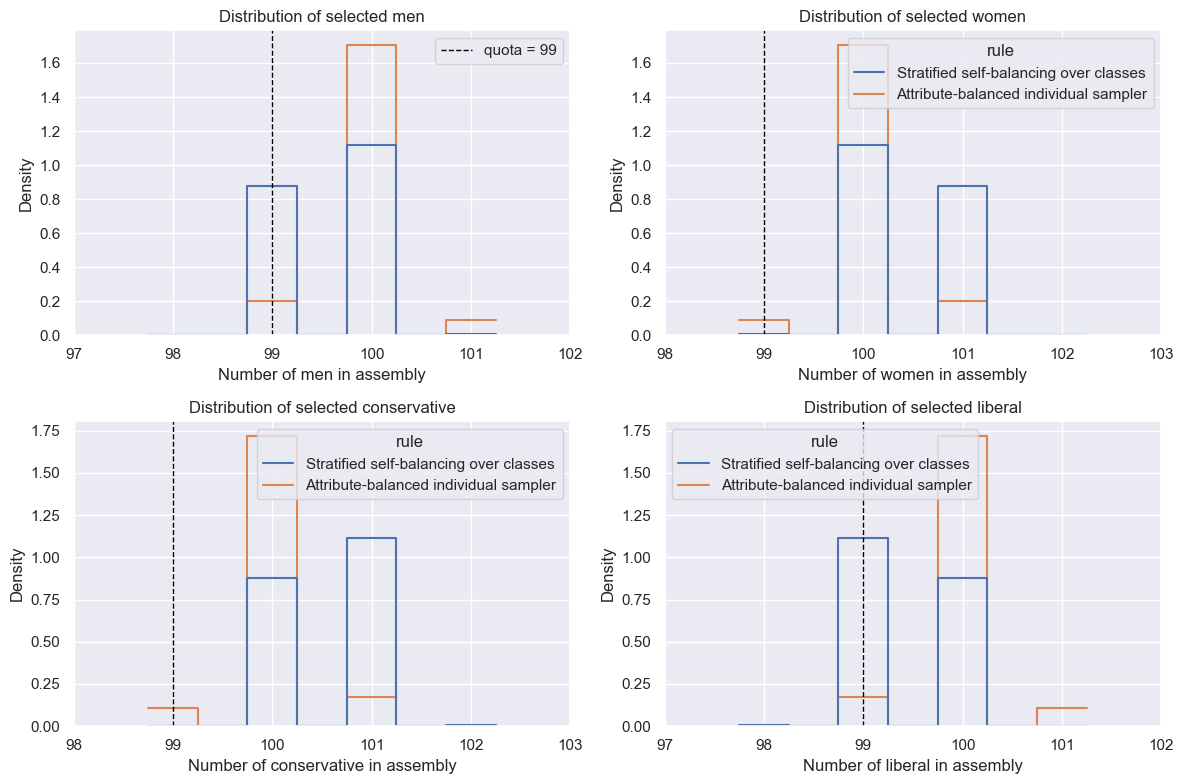

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
margin_names = ["men", "women", "conservative", "liberal"]

for ax, margin_name in zip(axes.flat, margin_names):
    observed_min = assembly_results[margin_name].min()
    observed_max = assembly_results[margin_name].max()
    bins = np.arange(observed_min - 0.25, observed_max + 0.75, 0.5)
    sns.histplot(
        data=assembly_results,
        x=margin_name,
        hue="rule",
        bins=bins,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.axvline(99, color="black", linestyle="--", linewidth=1, label="quota = 99")
    ax.set_xlim(observed_min - 1, observed_max + 1)
    ax.set_title(f"Distribution of selected {margin_name}")
    ax.set_xlabel(f"Number of {margin_name} in assembly")

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles=handles, labels=labels)
plt.tight_layout()
plt.show()


Plot the distribution of selection probabilities for each individual. Calculate the minimum selection probability.

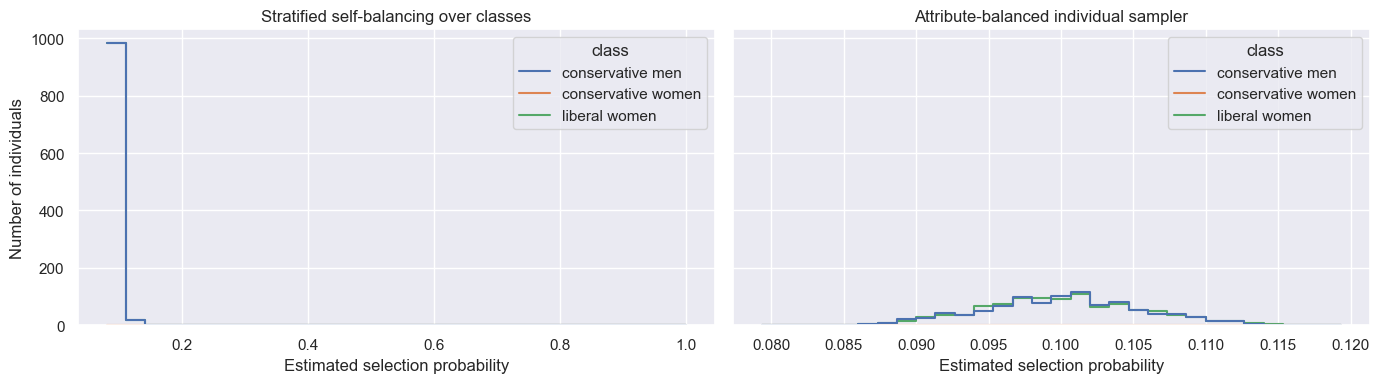

min      mean  \
rule                                   class                                    
Attribute-balanced individual sampler  conservative men    0.079333  0.099945   
                                       conservative women  0.087333  0.087333   
                                       liberal women       0.084000  0.100067   
Stratified self-balancing over classes conservative men    0.081333  0.099562   
                                       conservative women  1.000000  1.000000   
                                       liberal women       0.083000  0.099538   

                                                                max  
rule                                   class                         
Attribute-balanced individual sampler  conservative men    0.117333  
                                       conservative women  0.087333  
                                       liberal women       0.119333  
Stratified self-balancing over classes conservative men    0.115667  
                                       conservative women  1.000000  
                                       liberal women       0.117000

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, rule_name in zip(axes, samplers):
    subset = individual_probability_results[individual_probability_results["rule"] == rule_name]
    sns.histplot(
        data=subset,
        x="estimated_selection_probability",
        hue="class",
        bins=30,
        element="step",
        fill=False,
        stat="count",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(rule_name)
    ax.set_xlabel("Estimated selection probability")

axes[0].set_ylabel("Number of individuals")
plt.tight_layout()
plt.show()

individual_probability_results.groupby(["rule", "class"])["estimated_selection_probability"].agg(["min", "mean", "max"])
